<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week10/Day6/ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from scipy import stats
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import norm, binom, pearsonr, spearmanr

**🌟 Exercise 1: Basic Usage of SciPy**

**Task:** Import the SciPy library and explore its version.

In [6]:
import scipy
print(f"SciPy version : {scipy.__version__}")

SciPy version : 1.16.3


**🌟 Exercise 2: Descriptive Statistics**

Given a sample dataset, calculate the mean, median, variance, and standard deviation using SciPy.

Sample Dataset: data = [12, 15, 13, 12, 18, 20, 22, 21]

In [7]:
data = [12, 15, 13, 12, 18, 20, 22, 21]

desc = stats.describe(data)   # scipy.stats = count, min, max, media, variance

median = np.median(data)   # median not included in scipy

print(f"Mean   : {desc.mean:.4f}")
print(f"Median : {median:.4f}")
print(f"Variance: {desc.variance:.4f}")

Mean   : 16.6250
Median : 16.5000
Variance: 17.1250


**🌟 Exercise 3: Understanding Distributions**

* Generate a normal distribution using SciPy with a mean of 50 and a standard deviation of 10. Plot this distribution.

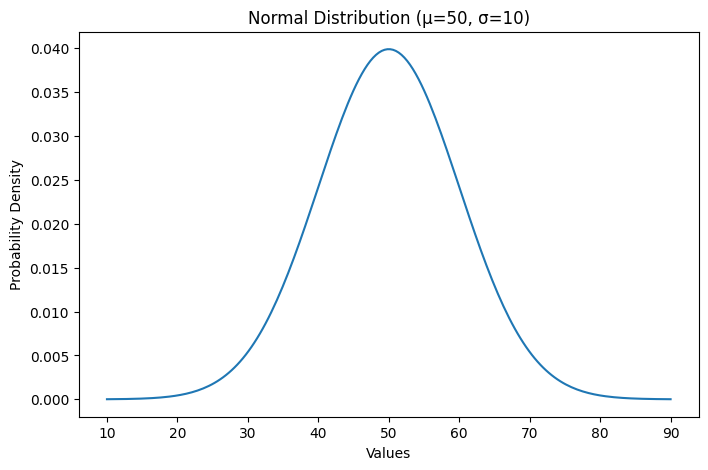

In [8]:
mean = 50
std = 10

x = np.linspace(10, 90, 200)  # range of values: 200 points between 10 and 90
y = norm.pdf(x, mean, std)    # scipy.stats import norm --> # normal distribution

plt.figure(figsize=(8,5))
plt.plot(x, y)
plt.title("Normal Distribution (μ=50, σ=10)")
plt.xlabel("Values")
plt.ylabel("Probability Density")
plt.show()

**🌟 Exercise 4: T-Test Application**

* Perform a T-test on two sets of randomly generated data.


Step 1: State hypothesis
  H0: mean data1 == mean data2
  H1: mean data1 != mean data2
  α = 0.05

Step 2: Examine the groups
  data1 : n=100, mean=48.962, std=9.082
  data2 : n=100, mean=60.223, std=9.537
 Observed difference: -11.262

Step 3: Run the test
 t-statistic: -8.551
 p-value: 0.00000

Step 4: Decision
 THERE IS enough statistically significant difference in data between version 1 and 2



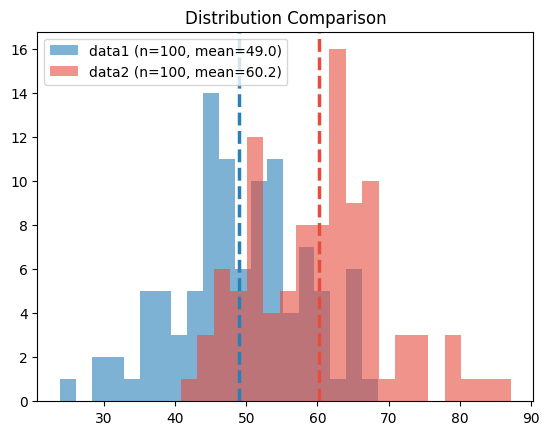

In [10]:

np.random.seed(42)

data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

print("\nStep 1: State hypothesis")
print(f"  H0: mean data1 == mean data2")
print(f"  H1: mean data1 != mean data2")
print(f"  α = 0.05")

print("\nStep 2: Examine the groups")
print(f"  data1 : n={len(data1)}, mean={np.mean(data1):.3f}, std={np.std(data1, ddof=1):.3f}")
print(f"  data2 : n={len(data2)}, mean={np.mean(data2):.3f}, std={np.std(data2, ddof=1):.3f}")
print(f" Observed difference: {np.mean(data1) - np.mean(data2):.3f}")

print("\nStep 3: Run the test")
t_stat, p_value = stats.ttest_ind(data1, data2)    #t_stat, p_value = stats.ttest_ind
print(f" t-statistic: {t_stat:.3f}")
print(f" p-value: {p_value:.5f}")

print("\nStep 4: Decision")
alpha = 0.05
if p_value < alpha:
  print(" THERE IS enough statistically significant difference in data between version 1 and 2")
else:
  print(" There is NOT enough evidence of a significant difference in the data between version 1 and 2")

print()

  # Histogram
plt.hist(data1, bins=20, alpha=0.6, color="#2980B9", label=f"data1 (n={len(data1)}, mean={np.mean(data1):.1f})")
plt.hist(data2, bins=20, alpha=0.6, color="#E74C3C", label=f"data2 (n={len(data2)}, mean={np.mean(data2):.1f})")
plt.axvline(np.mean(data1), color="#2980B9", lw=2.5, linestyle="--")
plt.axvline(np.mean(data2), color="#E74C3C", lw=2.5, linestyle="--")
plt.title("Distribution Comparison")
plt.legend()

**🌟 Exercise 5: Linear Regression Analysis**

Apply linear regression to a dataset and interpret the results.

Given a dataset of housing prices (house_prices) and their corresponding sizes (house_sizes), use linear regression to predict the price of a house given its size.

**Questions:**

* What is the slope and intercept of the regression line?
* Predict the price of a house that is 90 square meters.
* Interpret the meaning of the slope in the context of housing prices.

Regression Results
Slope: 1,828.77
Slope means: how much does the price increase for each additional m²

Intercept: 64,383.56
Intercept means: Estimated price when size is 0 (mainly a mathematical reference point).

Predicted price of a house for 90m²: 228,972.60

R²: 0.988 - proportion of price variation explained by house size.


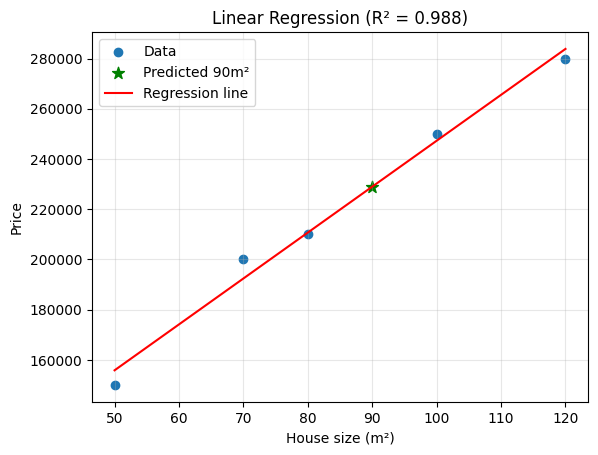

In [11]:
house_sizes = np.array([50, 70, 80, 100, 120])   #in square meters
house_prices = np.array([150000, 200000, 210000, 250000, 280000])  #in currency units

result = stats.linregress(house_sizes, house_prices)

print("Regression Results")
print(f"Slope: {result.slope:,.2f}")
print('Slope means: how much does the price increase for each additional m²')
print()
print(f"Intercept: {result.intercept:,.2f}")
print('Intercept means: Estimated price when size is 0 (mainly a mathematical reference point).')
print()

predicted_price = result.slope * 90 + result.intercept
print(f"Predicted price of a house for 90m²: {predicted_price:,.2f}")
print()

r_sq = result.rvalue ** 2
print(f"R²: {r_sq:.3f} - proportion of price variation explained by house size.")

# Regression line
x_line = np.linspace(house_sizes.min(), house_sizes.max(), 100)
y_line = result.slope * x_line + result.intercept

# Plot
plt.scatter(house_sizes, house_prices, label="Data")
plt.scatter(90, predicted_price, color="green", s=80, marker="*", label="Predicted 90m²")
plt.legend()
plt.plot(x_line, y_line, color="red", label="Regression line")
plt.xlabel("House size (m²)")
plt.ylabel("Price")
plt.title(f"Linear Regression (R² = {r_sq:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**🌟 Exercise 6: Understanding ANOVA**

**Objective:** Test understanding of ANOVA and its application.

Three different fertilizers are applied to three separate groups of plants to test their effectiveness. The growth in centimeters is recorded.

**Dataset:**

fertilizer_1: [5, 6, 7, 6, 5]

fertilizer_2: [7, 8, 7, 9, 8]

fertilizer_3: [4, 5, 4, 3, 4]

**Questions:**

* Perform an ANOVA test on the given data. What are the F-value and P-value?
* Based on the P-value, do the fertilizers have significantly different effects on plant growth?
* Explain what would happen if the P-value were greater than 0.05.


Step 1: State hypothesis

H₀: all fertilizers have the same effect on growth
H₁: At least one fertilizer produces different growth
  α = 0.05

Step 2: Examine the groups
Fertilizer 1: n=5, mean=5.80, std=0.84
Fertilizer 2: n=5, mean=7.80, std=0.84
Fertilizer 3: n=5, mean=4.00, std=0.71

Step 3: Run the test - Results ANOVA
F-value: 28.526
p-value: 0.00003

Step 4: Decision
Reject H₀: Fertilizers show statistically significant differences in plant growth.
At least one fertilizer produces different plant growth.



/tmp/ipykernel_6321/1841569915.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Fertilizer 1", "Fertilizer 2", "Fertilizer 3"])


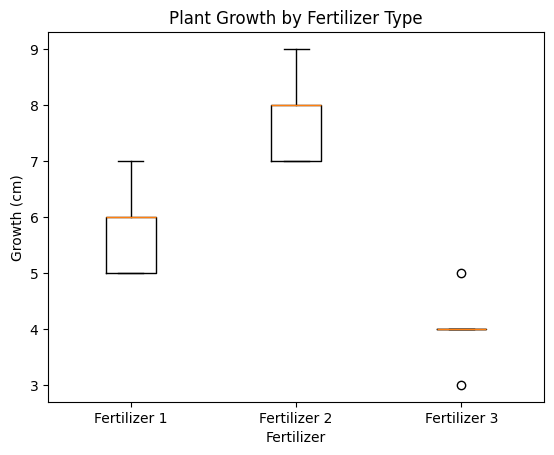

In [12]:
fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

print("\nStep 1: State hypothesis")
print("\nH₀: all fertilizers have the same effect on growth")
print("H₁: At least one fertilizer produces different growth")
print(f"  α = 0.05")

print("\nStep 2: Examine the groups")
groups = [fertilizer_1, fertilizer_2, fertilizer_3]

for i, g in enumerate(groups, start=1):
    print(f"Fertilizer {i}: n={len(g)}, mean={np.mean(g):.2f}, std={np.std(g, ddof=1):.2f}")


print("\nStep 3: Run the test - Results ANOVA")
f_value, p_value = stats.f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)    # f_value, p_value = stats.f_oneway
print(f"F-value: {f_value:.3f}")
print(f"p-value: {p_value:.5f}")

print("\nStep 4: Decision")
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Fertilizers show statistically significant differences in plant growth.")
    print('At least one fertilizer produces different plant growth.')

else:
    print("Fail to reject H₀: No significant difference between fertilizers.")

print()

# Visualization
plt.boxplot(groups, labels=["Fertilizer 1", "Fertilizer 2", "Fertilizer 3"])
plt.title("Plant Growth by Fertilizer Type")
plt.ylabel("Growth (cm)")
plt.xlabel("Fertilizer")
plt.show()

print()

# If p-value > 0.05, we would fail to reject the null hypothesis.
#   * There is not enough statistical evidence to say the fertilizers have different effects.
#   * Any observed differences in plant growth could be due to random variation rather than the fertilizer type.
#   * We could not claim that one fertilizer performs better than the others based on the data.

**🌟 Exercise 7: Probability Distributions**

* Work with a binomial distribution: calculate probabilities for different numbers of successes.
* Example: Calculating the probability of getting exactly 5 heads in 10 coin flips.

In [15]:
# probability of exactly 5 heads
prob = binom.pmf(k=5, n=10, p=0.5)   #binom.pmf

print(f"Probability of exactly 5 heads: {prob:.4f}")

# ≈ 24.6% probability of getting 5 heads in 10 tosses.

Probability of exactly 5 heads: 0.2461


**🌟 Exercise 8: Correlation Coefficients**

Calculate the Pearson and Spearman correlation coefficients between two variables in a dataset.

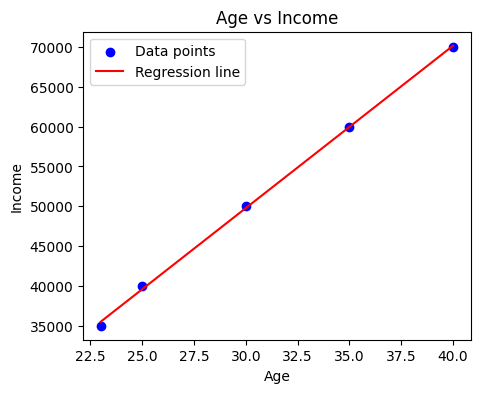

Pearson correlation: 0.9997 (p-value: 0.0000)
Spearman correlation: 1.0000 (p-value: 0.0000)


In [16]:
data = pd.DataFrame({'age': [23, 25, 30, 35, 40],
                     'income': [35000, 40000, 50000, 60000, 70000]})

# scatter plot with regression lin
plt.figure(figsize=(5,4))
plt.scatter(data['age'], data['income'], color='blue', label='Data points')
m, b = np.polyfit(data['age'], data['income'], 1)
plt.plot(data['age'], m*data['age'] + b, color='red', label='Regression line')

plt.title("Age vs Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.show()

# Pearson correlation
pearson_corr, p_value_pearson = pearsonr(data['age'], data['income'])
print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {p_value_pearson:.4f})")

# Spearman correlation
spearman_corr, p_value_spearman = spearmanr(data['age'], data['income'])
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {p_value_spearman:.4f})")